In [1]:
%load_ext sql
%config SqlMagic.autopandas = True  # Automatically convert query results to pandas dataframes
%sql duckdb://

Connecting to 'duckdb://'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('NCD_RisC_Nature_2020_Cholesterol_age_specific_countries_sql.csv').reset_index(drop = True)
#df

In [18]:
%%sql
drop table if exists temp_a;
create table temp_a
as select * 
from 'NCD_RisC_Nature_2020_Cholesterol_age_specific_countries_sql.csv'
where columns(*) is not null;
/*select * 
from temp_a
limit 5*/


Running query in 'duckdb://'

,Success


In [19]:
%%sql
select count (*)
from temp_a

Running query in 'duckdb://'

,count_star()
0,234000


In [20]:
%%sql
drop table if exists temp_men;
create table temp_men
as select *
from temp_a
where Gender = 'Men';
select *
from temp_men
limit 5

Running query in 'duckdb://'

,Country,Year,Gender,Age_group,Mean_total_cholesterol_mmolL,Mean_total_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_total_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_mmolL,Mean_non_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_mmolL,Mean_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL
0,Afghanistan,1980,Men,18-19,3.938280,3.408243,4.450841,2.390296,1.786243,3.001487,1.203759,0.903827,1.491221
1,Afghanistan,1980,Men,20-24,4.030348,3.461665,4.583069,2.565352,2.025941,3.104508,1.207433,0.912178,1.486294
2,Afghanistan,1980,Men,25-29,4.152129,3.523245,4.771284,2.781679,2.317325,3.244324,1.209319,0.917293,1.482287
3,Afghanistan,1980,Men,30-34,4.257240,3.571934,4.923948,2.955077,2.523206,3.386726,1.209177,0.918113,1.481715
4,Afghanistan,1980,Men,35-39,4.339896,3.612904,5.052363,3.081967,2.652806,3.506228,1.209154,0.917683,1.481755


In [21]:
%%sql
select count (*)
from temp_men

Running query in 'duckdb://'

,count_star()
0,117000


In [22]:
%%sql
drop table if exists temp_women;
create table temp_women
as select *
from temp_a
where Gender = 'Women';
select *
from temp_women
limit 5

Running query in 'duckdb://'

,Country,Year,Gender,Age_group,Mean_total_cholesterol_mmolL,Mean_total_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_total_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_mmolL,Mean_non_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_non_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_mmolL,Mean_HDL_cholesterol_lower_95_percent_uncertainty_interval_mmolL,Mean_HDL_cholesterol_upper_95_percent_uncertainty_interval_mmolL
0,Afghanistan,1980,Women,18-19,3.830965,3.262239,4.382165,2.500176,1.843854,3.160560,1.156468,0.826166,1.478740
1,Afghanistan,1980,Women,20-24,3.895367,3.330554,4.460793,2.558884,1.977079,3.131051,1.164609,0.846169,1.473201
2,Afghanistan,1980,Women,25-29,3.985470,3.409383,4.562613,2.648247,2.150866,3.152602,1.168161,0.855529,1.468792
3,Afghanistan,1980,Women,30-34,4.075347,3.491439,4.662949,2.744793,2.302104,3.184211,1.165383,0.853204,1.459801
4,Afghanistan,1980,Women,35-39,4.167230,3.565944,4.778721,2.849322,2.435332,3.262373,1.159804,0.846003,1.458042


In [23]:
%%sql
select count (*)
from temp_women

Running query in 'duckdb://'

,count_star()
0,117000


In [67]:
%%sql
drop table if exists temp_men_max_min;
create table temp_men_max_min
as select Country, min(Mean_total_cholesterol_mmolL), max(Mean_total_cholesterol_mmolL),
    avg(Mean_total_cholesterol_mmolL)
from temp_men
group by Country
order by Country;
select *
from temp_men_max_min

Running query in 'duckdb://'

,Country,min(Mean_total_cholesterol_mmolL),max(Mean_total_cholesterol_mmolL),avg(Mean_total_cholesterol_mmolL)
0,Afghanistan,3.763371,4.445012,4.200434
1,Albania,4.092485,5.641840,5.100519
2,Algeria,3.575241,4.739149,4.355135
3,American Samoa,3.693864,5.337268,4.724860
4,Andorra,4.066586,6.581130,5.542656
...,...,...,...,...
195,Venezuela,3.770711,5.049943,4.702333
196,Viet Nam,3.500800,5.189597,4.362626
197,Yemen,3.818246,4.874329,4.498073
198,Zambia,3.347822,4.213344,3.936871


In [68]:
%%sql
drop table if exists temp_women_max_min;
create table temp_women_max_min
as select Country, min(Mean_total_cholesterol_mmolL), max(Mean_total_cholesterol_mmolL),
    avg(Mean_total_cholesterol_mmolL)
from temp_women
group by Country
order by Country;
select *
from temp_women_max_min

Running query in 'duckdb://'

,Country,min(Mean_total_cholesterol_mmolL),max(Mean_total_cholesterol_mmolL),avg(Mean_total_cholesterol_mmolL)
0,Afghanistan,3.830965,4.652381,4.292196
1,Albania,4.073694,6.340525,5.340842
2,Algeria,3.815877,5.019636,4.528192
3,American Samoa,3.993148,5.864000,4.972367
4,Andorra,4.335035,7.026147,5.690532
...,...,...,...,...
195,Venezuela,3.869271,5.617545,5.011274
196,Viet Nam,3.626412,5.374247,4.430975
197,Yemen,3.926057,4.964503,4.530223
198,Zambia,3.705256,4.525014,4.200557


In [69]:
df_min_max_men = %sql select * from temp_men_max_min
df_min_max_men

Running query in 'duckdb://'

,Country,min(Mean_total_cholesterol_mmolL),max(Mean_total_cholesterol_mmolL),avg(Mean_total_cholesterol_mmolL)
0,Afghanistan,3.763371,4.445012,4.200434
1,Albania,4.092485,5.641840,5.100519
2,Algeria,3.575241,4.739149,4.355135
3,American Samoa,3.693864,5.337268,4.724860
4,Andorra,4.066586,6.581130,5.542656
...,...,...,...,...
195,Venezuela,3.770711,5.049943,4.702333
196,Viet Nam,3.500800,5.189597,4.362626
197,Yemen,3.818246,4.874329,4.498073
198,Zambia,3.347822,4.213344,3.936871


In [70]:
df_min_max_men.dtypes

Country                               object
min(Mean_total_cholesterol_mmolL)    float64
max(Mean_total_cholesterol_mmolL)    float64
avg(Mean_total_cholesterol_mmolL)    float64
dtype: object

In [71]:
df_min_max_women = %sql select * from temp_women_max_min
df_min_max_women

Running query in 'duckdb://'

,Country,min(Mean_total_cholesterol_mmolL),max(Mean_total_cholesterol_mmolL),avg(Mean_total_cholesterol_mmolL)
0,Afghanistan,3.830965,4.652381,4.292196
1,Albania,4.073694,6.340525,5.340842
2,Algeria,3.815877,5.019636,4.528192
3,American Samoa,3.993148,5.864000,4.972367
4,Andorra,4.335035,7.026147,5.690532
...,...,...,...,...
195,Venezuela,3.869271,5.617545,5.011274
196,Viet Nam,3.626412,5.374247,4.430975
197,Yemen,3.926057,4.964503,4.530223
198,Zambia,3.705256,4.525014,4.200557


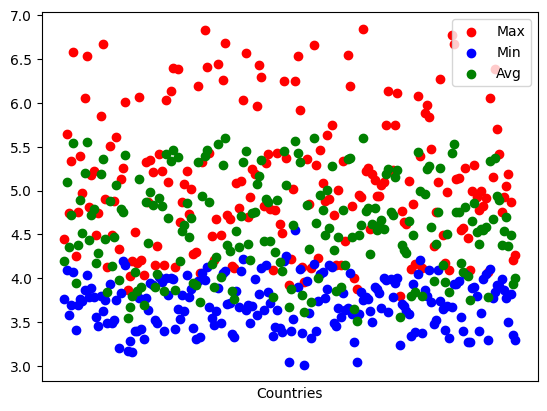

In [72]:
x = df_min_max_men['Country']
y1 = df_min_max_men['max(Mean_total_cholesterol_mmolL)']
y2 = df_min_max_men['min(Mean_total_cholesterol_mmolL)']
y3 = df_min_max_men['avg(Mean_total_cholesterol_mmolL)']

plt.scatter(x, y1, color = 'red', label = 'Max')
plt.scatter(x, y2, color = 'blue', label = 'Min')
plt.scatter(x, y3, color = 'green', label = 'Avg')
plt.xticks([])
plt.xlabel('Countries')
plt.legend()
plt.show()

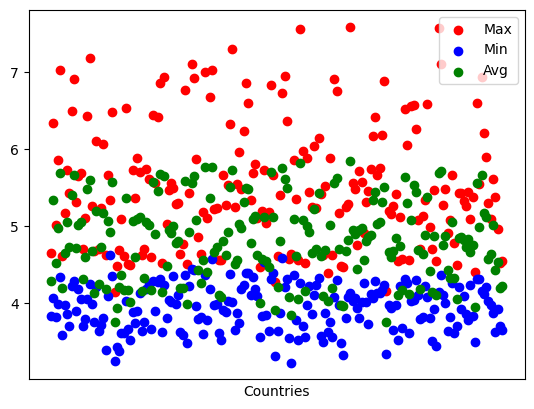

In [73]:
x = df_min_max_women['Country']
y1 = df_min_max_women['max(Mean_total_cholesterol_mmolL)']
y2 = df_min_max_women['min(Mean_total_cholesterol_mmolL)']
y3 = df_min_max_women['avg(Mean_total_cholesterol_mmolL)']

plt.scatter(x, y1, color = 'red', label = 'Max')
plt.scatter(x, y2, color = 'blue', label = 'Min')
plt.scatter(x, y3, color = 'green', label = 'Avg')
plt.xticks([])
plt.xlabel('Countries')
plt.legend()
plt.show()